In [6]:
!pip install tensorflow pandas numpy scikit-learn

In [7]:
# importing libraries
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM, GRU

Downloading the Dataset from Kaggle

In [8]:
# Download dataset
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/
License(s): other
imdb-dataset-of-50k-movie-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)


In [9]:
import zipfile

zip_path = "imdb-dataset-of-50k-movie-reviews.zip"
extract_path = "/content/imdb"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully!")

Extracted successfully!


In [13]:
# loading the dataset
df = pd.read_csv("/content/imdb/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [14]:
df.shape

(50000, 2)

In [15]:
df['sentiment'].value_counts() # balanced dataset

,count
sentiment,
positive,25000
negative,25000


In [16]:
# Preprocessing of Dataset
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df.sample(5)

,review,sentiment
12571,"Beyond the excellent direction,production,acti...",1
40940,"To put it simply, I am not fond of westerns. A...",0
32966,"This movie portrays Ruth as a womanizing, hard...",0
33025,Belushi at his most ingratiating and Courtney ...,1
13099,"Conrad Radzoff(Ferdy Mayne), a hammy cult icon...",0


In [17]:
df['sentiment'].value_counts() # for checking

,count
sentiment,
1,25000
0,25000


In [18]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(df['review'], df['sentiment'], test_size=0.2, random_state=42)

In [19]:
X_train.shape

(40000,)

In [20]:
# tokenization and padding
vocab_size = 10000
max_length = 200

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

In [21]:
# Model -- RNN

rnn_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [24]:
rnn_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6684 - loss: 0.5198 - val_accuracy: 0.5577 - val_loss: 0.7390
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6666 - loss: 0.5090 - val_accuracy: 0.5989 - val_loss: 0.6925
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6866 - loss: 0.5018 - val_accuracy: 0.5583 - val_loss: 0.7298
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6917 - loss: 0.4806 - val_accuracy: 0.6049 - val_loss: 0.8349
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7072 - loss: 0.4536 - val_accuracy: 0.5924 - val_loss: 0.7788
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7067 - loss: 0.4404 - val_accuracy: 0.5604 - val_loss: 0.8792
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7102 - loss: 0.4330 - val_accuracy: 0.6099 - val_loss: 0.7840
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6972 - loss: 0.4622 - 

In [27]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (64, 200, 128)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (64, 64)               │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (64, 1)                │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,877,253 (14.79 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,584,836 (9.86 MB)

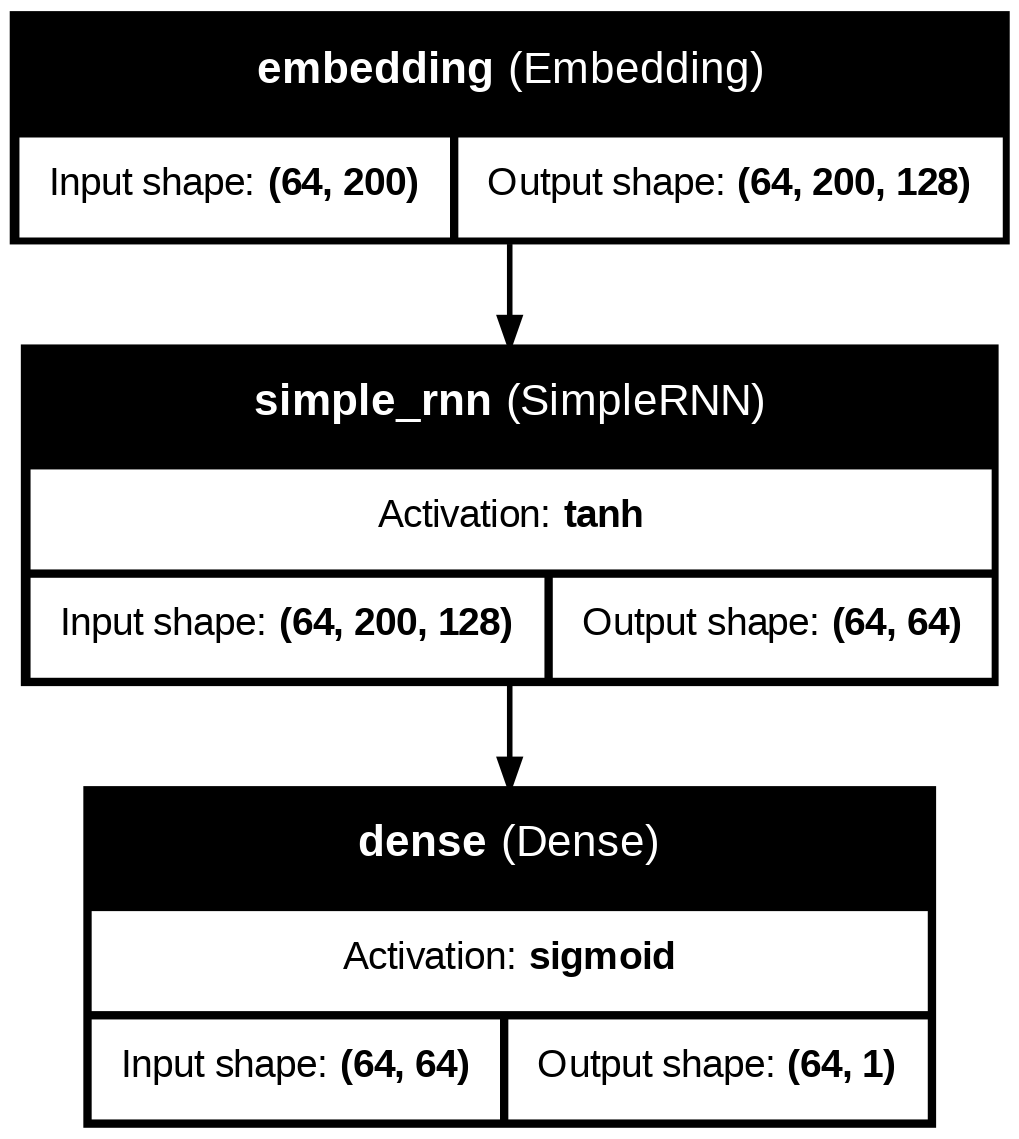

In [28]:
# plotting the model
from keras.utils import plot_model

# Architecture
plot_model(rnn_model, show_layer_names=True, show_layer_activations=True, show_shapes=True)

In [29]:
# Model -- LSTM

lstm_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [31]:
lstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_pad, y_test))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6194 - loss: 0.6290 - val_accuracy: 0.6236 - val_loss: 0.7231
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7504 - loss: 0.5041 - val_accuracy: 0.8517 - val_loss: 0.3504
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8910 - loss: 0.2748 - val_accuracy: 0.8884 - val_loss: 0.2674
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9252 - loss: 0.2020 - val_accuracy: 0.8900 - val_loss: 0.2681
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9453 - loss: 0.1550 - val_accuracy: 0.8828 - val_loss: 0.3063
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9637 - loss: 0.1138 - val_accuracy: 0.8828 - val_loss: 0.3217
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9770 - loss: 0.0817 - val_accuracy: 0.8821 - val_loss: 0.3532
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9837 - loss: 0.0614 - val_ac

In [35]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (64, 200, 128)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (64, 64)               │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (64, 1)                │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,988,421 (15.21 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,658,948 (10.14 MB)

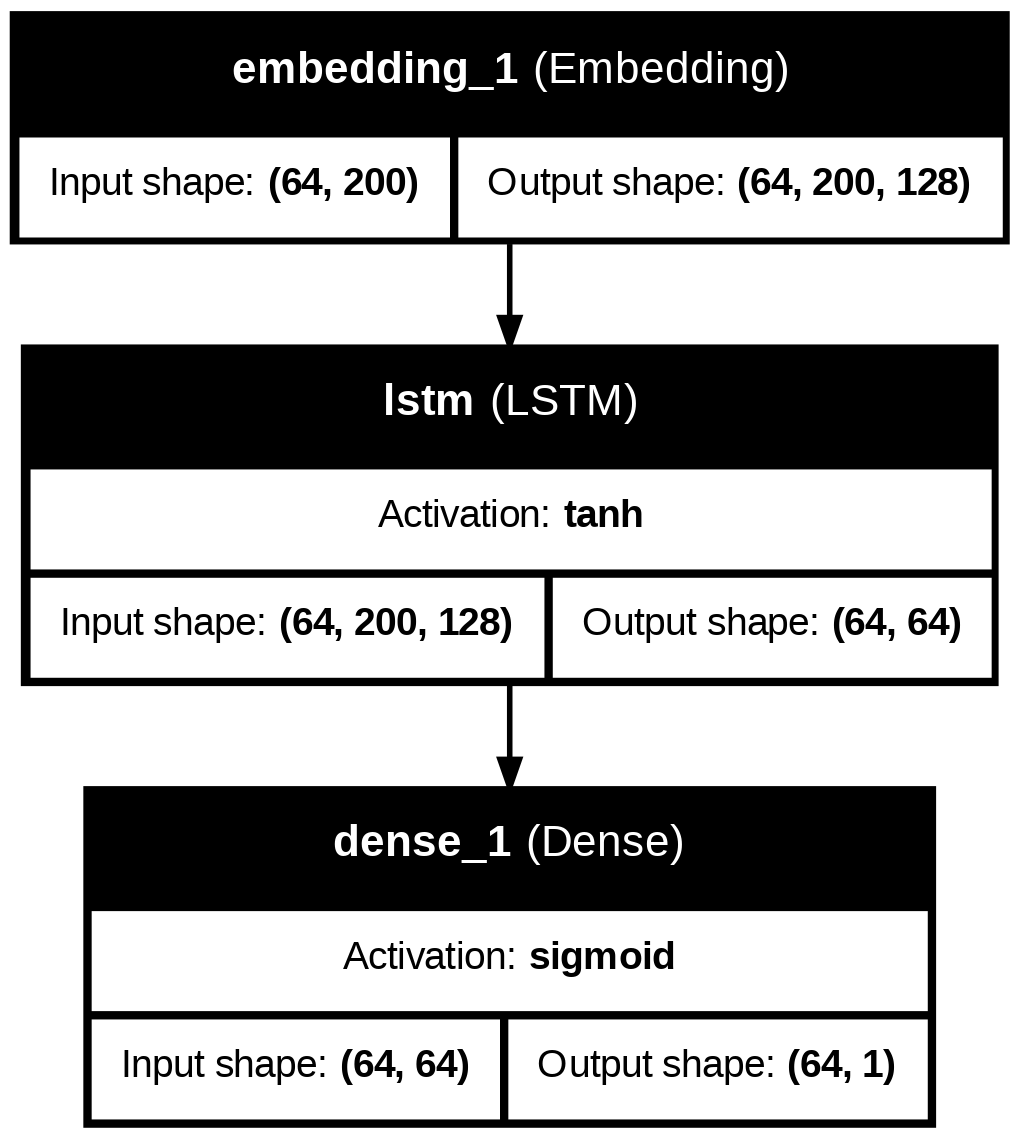

In [36]:
# plotting the model
from keras.utils import plot_model

# Architecture
plot_model(lstm_model, show_layer_names=True, show_layer_activations=True, show_shapes=True)

In [37]:
# Model -- GRU

gru_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    GRU(64),
    Dense(1, activation='sigmoid')
])

gru_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [38]:
gru_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_pad, y_test))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.6137 - loss: 0.6497 - val_accuracy: 0.7695 - val_loss: 0.5772
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8290 - loss: 0.3932 - val_accuracy: 0.8712 - val_loss: 0.3233
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9019 - loss: 0.2485 - val_accuracy: 0.8934 - val_loss: 0.2726
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9346 - loss: 0.1771 - val_accuracy: 0.8945 - val_loss: 0.2695
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9557 - loss: 0.1299 - val_accuracy: 0.8898 - val_loss: 0.3059
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9686 - loss: 0.0962 - val_accuracy: 0.8791 - val_loss: 0.3515
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9798 - loss: 0.0686 - val_accuracy: 0.8802 - val_loss: 0.3775
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9855 - loss: 0.0508 - val_ac

In [39]:
gru_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (64, 200, 128)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (64, 64)               │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (64, 1)                │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,951,941 (15.08 MB)

 Trainable params: 1,317,313 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,634,628 (10.05 MB)

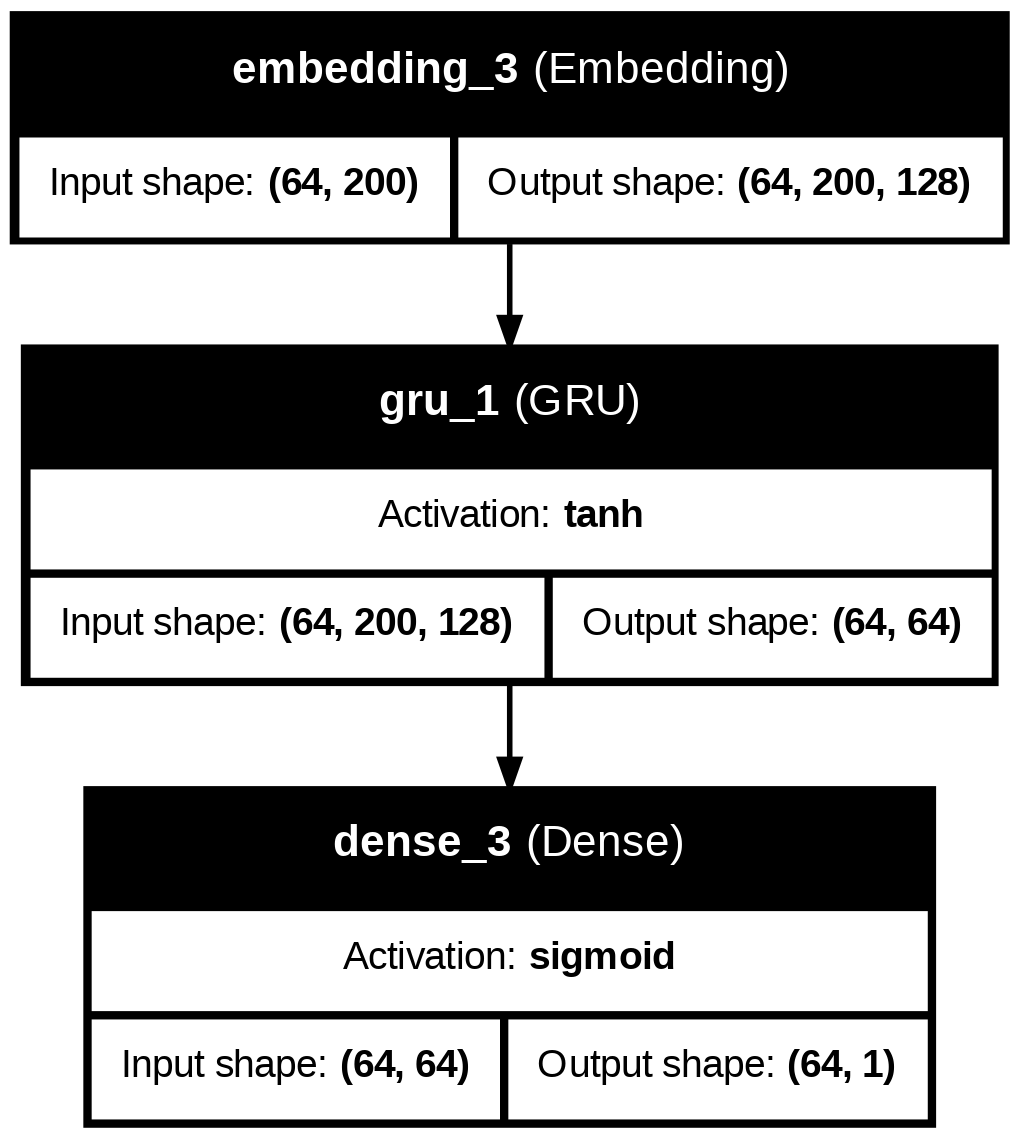

In [43]:
# plotting the model
from keras.utils import plot_model

# Architecture
plot_model(gru_model, show_layer_names=True, show_layer_activations=True, show_shapes=True)

In [45]:
# Evaluation of 3 models
print("RNN Accuracy:", rnn_model.evaluate(X_test_pad, y_test)[1])
print("LSTM Accuracy:", lstm_model.evaluate(X_test_pad, y_test)[1])
print("GRU Accuracy:", gru_model.evaluate(X_test_pad, y_test)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5838 - loss: 0.8907
RNN Accuracy: 0.5838000178337097
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8772 - loss: 0.5206
LSTM Accuracy: 0.8772000074386597
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8746 - loss: 0.5573
GRU Accuracy: 0.8745999932289124


In [46]:
# Testing the fucntion
def predict(model, text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_length, padding='post')
    prediction = model.predict(padded)[0][0]

    if prediction > 0.5:
        return "Positive"
    else:
        return "Negative"

In [47]:
models = {'RNN' : rnn_model,
          'LSTM': lstm_model,
          'GRU': gru_model}

for name, model in models.items():
  print(f"{name}:")
  print(predict(model, "This movie was absolutely amazing!"))

RNN:
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step
Positive
LSTM:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
Positive
GRU:
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 629ms/step
Positive


In [48]:
models = {'RNN' : rnn_model,
          'LSTM': lstm_model,
          'GRU': gru_model}

for name, model in models.items():
  print(f"{name}:")
  print(predict(model, "Poor storyline, waste of money!"))

RNN:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Positive
LSTM:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Negative
GRU:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Negative
